# IAT 461 — Assignment 4: Client Peer Project

## Context

### Entity

Kosima Production is a fictional video game development and player research company. The company studies player behaviour and public feedback to support decisions about game updates, technical improvements, and community communication. For this project, Kosima Production is examining Steam reviews of Cyberpunk 2077, an open-world role-playing game with a large and active player community. The company wants to understand why some players leave negative reviews and which concerns should receive the most attention.

### Business Context and Strategic Options

Cyberpunk 2077 has received a large number of Steam reviews containing feedback about technical performance, gameplay systems, story content, controls, and other parts of the player experience. The overall review score shows whether players recommend the game, but it does not clearly explain the reasons behind negative reviews.

Kosima Production is considering three possible strategies:
- Option A: Increase advertising and promotional activities to attract more players.
- Option B: Improve general community communication by publishing more announcements, development updates, and responses to player questions.
- Option C: Analyze negative Steam reviews to discover the technical and gameplay concerns that players mention most often, then use these findings to prioritize future improvements.


### Task

#### Phase 1, EDA and Strategy Validation

Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

#### Phase 2, Data Science Implementation

Assuming Kosima Production proceeds with Option C, group the English-language negative reviews according to their underlying complaint themes. The analysis should not begin with a predefined list of issue categories. Instead, the themes should be discovered from similarities in the language used in the reviews.

After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.


## Imports

In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk

from spacy.lang.en.stop_words import STOP_WORDS
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

## Initial Steps

### Loading Dataset

We will first take a look at the dataset our client provided for us.

In [11]:
df = pd.read_csv("Cyberpunk_2077_English_Reviews_Final.csv")
df.head(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
0,81918897,Rommel,Recommended,"""Hᴇ's ғᴜᴄᴋᴇᴅ ɪɴ ᴛʜᴇ ʜᴇᴀᴅ, ᴛʜᴇ ᴡᴏʀʟᴅ's ғᴜᴄᴋᴇᴅ ɪ...",12/9/2020,401.5,22,False,Release,en
1,81918903,76561198038931832,Recommended,It's a city of dreams... and I'm a big dreamer.,12/9/2020,247.6,710,True,Release,en
2,81918912,limbo97,Recommended,Obligatory It's breathtaking!A wonderful sci-f...,12/9/2020,8.8,19,False,Release,en
3,81918918,sn1ffla,Not Recommended,"Bigot developerTo clarify, I got this game fro...",12/9/2020,86.1,18,True,Release,en
4,81918924,MeliGL,Recommended,Still waiting to be able to play.Edit: I'm not...,12/9/2020,34.9,0,False,Release,en


### Inspecting the Data

Next, we'll be inspecting the data for their types, structure, and any missing values.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ReviewID           365388 non-null  int64 
 1   SteamID            365388 non-null  object
 2   Rating             365388 non-null  object
 3   Review             362569 non-null  object
 4   Date Posted        365388 non-null  object
 5   Hours Played       365388 non-null  object
 6   Voted Helpful      365388 non-null  object
 7   Received for Free  365388 non-null  bool  
 8   Update             365388 non-null  object
 9   Detected Language  365388 non-null  object
dtypes: bool(1), int64(1), object(8)
memory usage: 25.4+ MB


Seems like we're only missing a few thousand reviews. We'll keep these in for now as the extra data is helpful and filter them out later during our text processing.

In [16]:
df.sample(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
300120,147044796,76561199300020979,Recommended,Good work,9/25/2023,14.4,0,False,Patch 2.0,en
89648,82470455,76561198190038309,Recommended,JOGO DO CARALHO PRIMO,12/15/2020,217.8,0,False,Hotfix 1.04,en
288777,141884342,76561199131619043,Recommended,all in all the game isnot bad if game workers ...,7/11/2023,59.5,0,False,Patch 1.63,en
150494,83828917,miesermiester,Not Recommended,"This is a shallow, unfished game. Graphics and...",1/2/2021,91.2,3,False,Hotfix 1.06,en
59851,82238186,76561198212312712,Recommended,Good,12/12/2020,84.1,0,False,Hotfix 1.04,en


Let's just make sure everything is in English:

In [18]:
df["Detected Language"].value_counts()

Detected Language
en    365388
Name: count, dtype: int64

And then looking at the balance of our ratings:

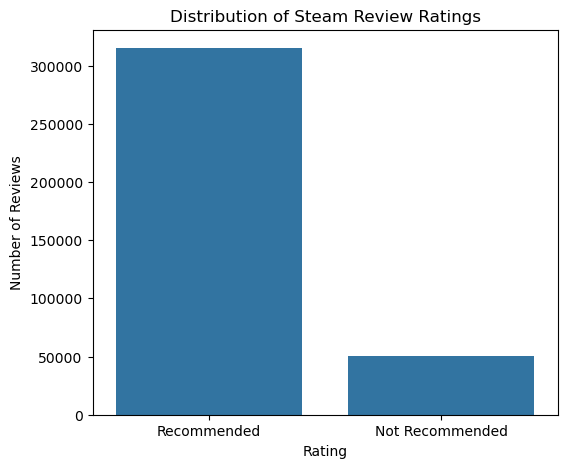

In [20]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Distribution of Steam Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
rating_percent = (
    df["Rating"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(rating_percent)

Rating
Recommended        86.21
Not Recommended    13.79
Name: proportion, dtype: float64


That's very unbalanced. We will address those later.

### Data Conversion

Let's just quickly update the fields `Hours Played` and `Voted Helpful` to the right data types:

In [25]:
df["Hours Played"] = (
    df["Hours Played"]
      .str.replace(",", "")
      .astype(float)
)

df["Voted Helpful"] = (
    df["Voted Helpful"]
      .str.replace(",", "")
      .astype(int)
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ReviewID           365388 non-null  int64  
 1   SteamID            365388 non-null  object 
 2   Rating             365388 non-null  object 
 3   Review             362569 non-null  object 
 4   Date Posted        365388 non-null  object 
 5   Hours Played       365388 non-null  float64
 6   Voted Helpful      365388 non-null  int32  
 7   Received for Free  365388 non-null  bool   
 8   Update             365388 non-null  object 
 9   Detected Language  365388 non-null  object 
dtypes: bool(1), float64(1), int32(1), int64(1), object(6)
memory usage: 24.0+ MB


Since our brief wants us to:

> Determine whether negative reviews are mainly connected to limited communication, certain types of players, **particular time periods**, or repeated technical and gameplay concerns.

We'll go ahead and convert `Date Posted` to datetime in anticipation of working with dates.

In [27]:
df["Date Posted"] = pd.to_datetime(
    df["Date Posted"],
    format="mixed", # this dataset has mixed formats I had found
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ReviewID           365388 non-null  int64         
 1   SteamID            365388 non-null  object        
 2   Rating             365388 non-null  object        
 3   Review             362569 non-null  object        
 4   Date Posted        365388 non-null  datetime64[ns]
 5   Hours Played       365388 non-null  float64       
 6   Voted Helpful      365388 non-null  int32         
 7   Received for Free  365388 non-null  bool          
 8   Update             365388 non-null  object        
 9   Detected Language  365388 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(1), object(5)
memory usage: 24.0+ MB


We'll also quickly add some other useful date times:

In [29]:
df["Year"] = df["Date Posted"].dt.year
df["YearMonth"] = df["Date Posted"].dt.to_period("M")

monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

print(monthly_reviews.head())

  YearMonth  Reviews
0   2020-12   148492
1   2021-01    21754
2   2021-02     5721
3   2021-03     4665
4   2021-04     3931


## Phase 1: EDA and Strategy Validation

> Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

### Review Timeline

Using the `Date Posted` field, we can just look through how reviews for the game look like throughout the months.

#### Reviews Over Time

First, let's get te total reviews over time.

In [36]:
monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

monthly_reviews["YearMonth"] = monthly_reviews["YearMonth"].astype(str)

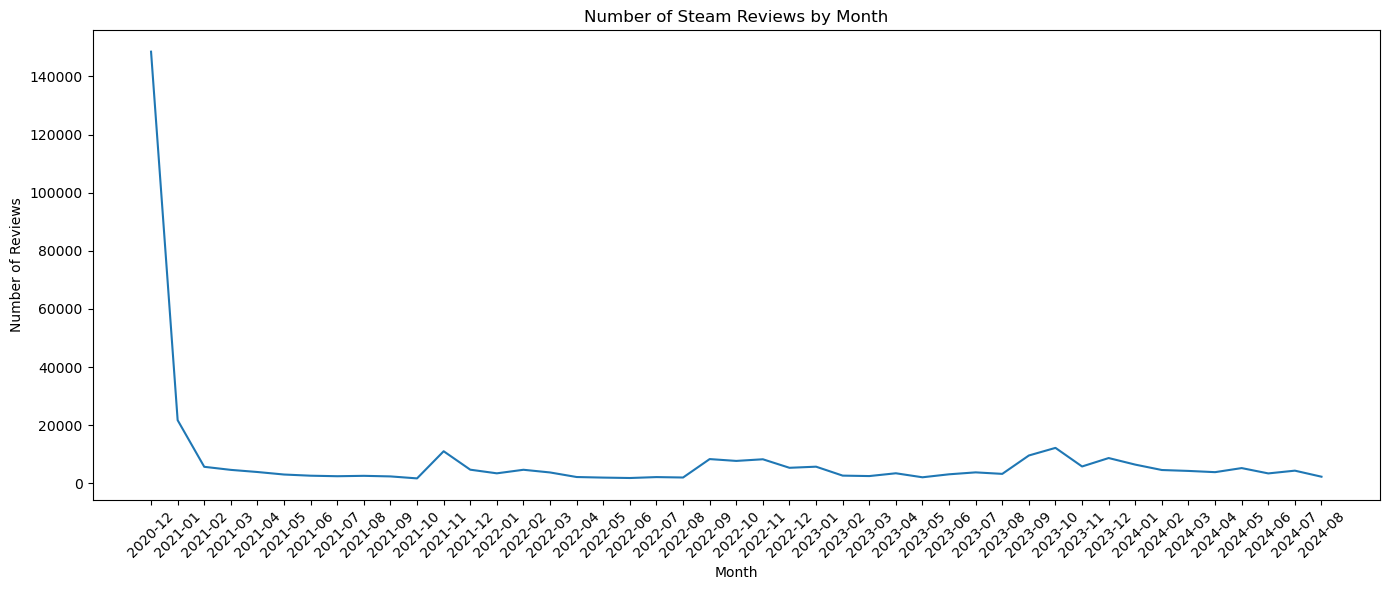

In [134]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_reviews["YearMonth"],
    monthly_reviews["Reviews"]
)

plt.xticks(rotation=45)

plt.title("Number of Steam Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

This shows that most reviews were written after launch, and trends upwards around November 2021, August 2022, and October 2023. Let's take a look at what patch these are:

In [139]:
df.loc[df["YearMonth"] == "2021-11", "Update"].value_counts()

Update
Patch 1.31    11071
Name: count, dtype: int64

Comes after one of the ["most significant update for the game yet"](https://www.notebookcheck.net/Cyberpunk-2077-Patch-1-3-is-the-most-significant-update-for-the-game-yet-with-over-33-GB-of-fixes-changes-and-improvements.555775.0.html). 

In [136]:
df.loc[df["YearMonth"] == "2022-09", "Update"].value_counts()

Update
Patch 1.6     8120
Patch 1.52     256
Name: count, dtype: int64

This set of reviews come after the [Cyberpunk: Edgerunners](https://www.cyberpunk.net/en/news/45280/edgerunners-update-patch-1-6-list-of-changes) update. This is a separate anime based on the game that possibly brought in new players to the game.

In [131]:
df.loc[df["YearMonth"] == "2023-10", "Update"].value_counts()

Update
Patch 2.01    8070
Patch 2.0     2690
Patch 2.02    1470
Name: count, dtype: int64

This set of reviews come after the [2.0 updates](https://expertgamereviews.com/cyberpunk-2077-2-update-complete-guide/). We can take a closer look by checking the positive vs. negative reviews over time:

#### Positive vs Negative over time

In [44]:
monthly_rating = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

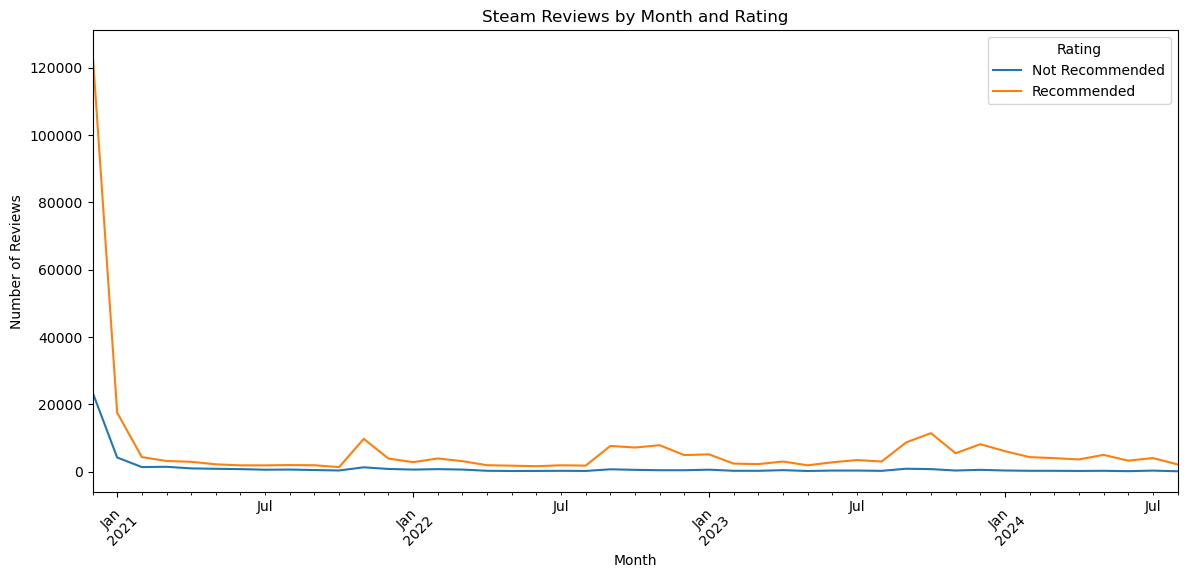

In [45]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

Overall, it looks like the negative reviews remained flat all throughout the time periods. There's a huge chunk at release, but the uptick in reviews seem to be positive in the ones we've identified above. Let's zoom in to take a closer look at the ratings:

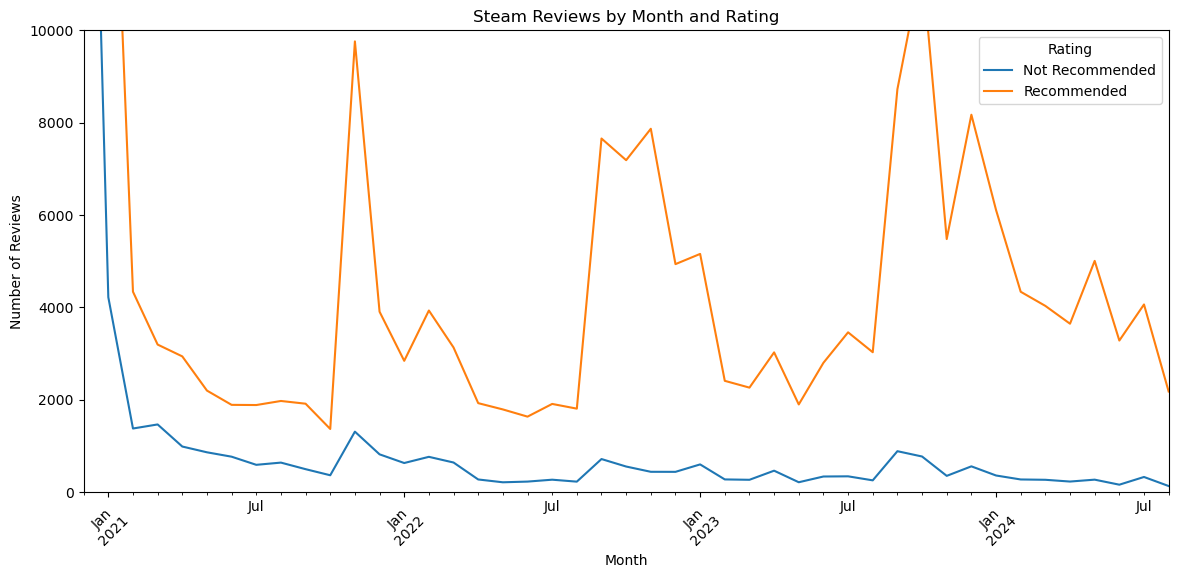

In [114]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.ylim(0, 10000) # set y limit to "zoom" in

plt.xticks(rotation=45)

plt.show()

Those trends in reviews we identified earlier (from certain updates) seem to be mostly positive reviews. Each wave of positive reviews come with a wave of negative reviews as well, however.

#### Percent of Negative Reviews

By looking at the percent of negative reviews to the rest of it, we can get a better picture of user sentiment throughout time.

In [48]:
monthly_counts = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

monthly_percent = monthly_counts.div(
    monthly_counts.sum(axis=1),
    axis=0
) * 100

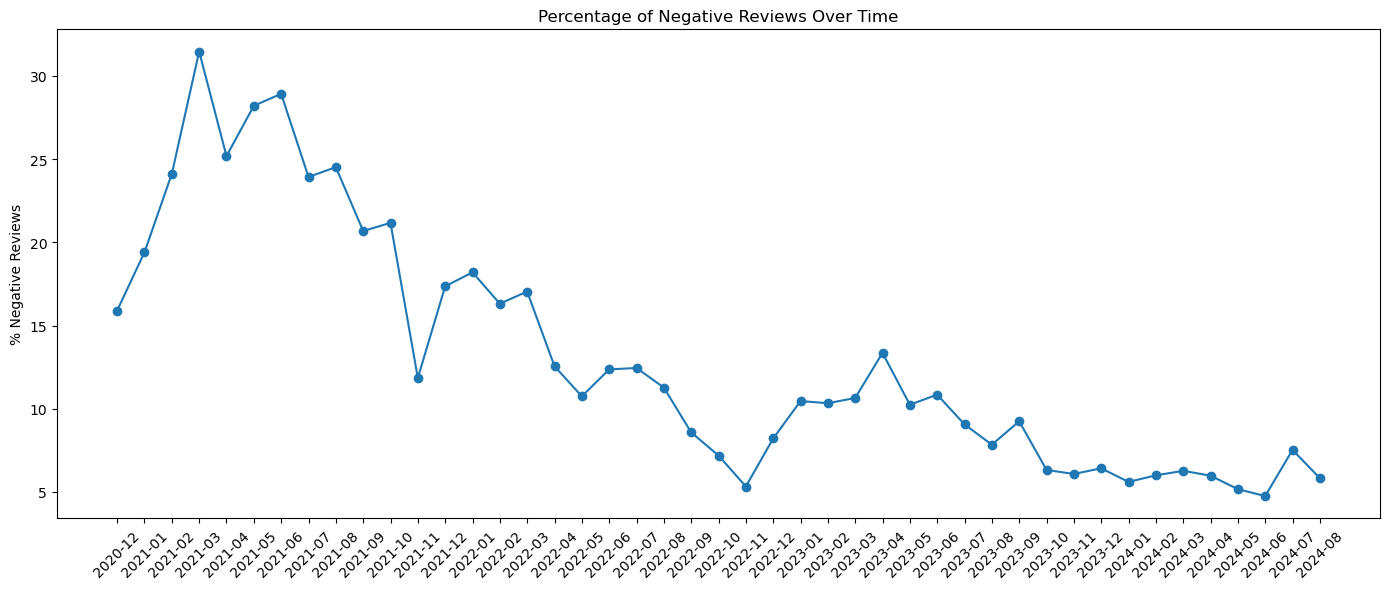

In [49]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_percent.index.astype(str),
    monthly_percent["Not Recommended"],
    marker="o"
)

plt.xticks(rotation=45)
plt.ylabel("% Negative Reviews")
plt.title("Percentage of Negative Reviews Over Time")
plt.tight_layout()
plt.show()

It looks like negative reviews (compared to positive reviews) percentage generally decrease over time with the exception of early release, December 2021, and May 2023. However, the graph above this one shows a more constant stream of negative reviews, meaning that rather than negative reviews dropping, positive reviews just overwhelm the percentages.

#### Interpretation and Analysis

Based on these findings, we see that negative reviews remain consistent throughout time, with the exception of major patches and releases (which end up stabilizing anyway). There were the most negative reviews upon launch, but generally trend downwards throughout time. With this in mind, let's evaluate the options so far:

**Option A - Advertising**: As negative reviews generally decrease over time, attracting more players would possibly result in more positive reviews. We can see this in the Cyberpunk: Edgerunners patch in Fall 2022. However, it is unclear whether or not attracting new players to the game would help us understand why some players leave negative reviews.

**Option B - Communication**: Our findings show that user sentiment to the game (through the percentage of Negative Reviews Over Time) decrease over time, especially after the hotfixes after major releases. It's likely that learning about bugs and fixing them right away lead to more player satisfaction, meaning we should consider Option B more closely.

**Option C - Complaint Analysis**: Unclear so far.

### Player Characteristics

We can take a look at the characteristics of the players (playtime & if they received the game for free).

#### Hours Played vs Rating

First, let's quickly just look at the summary statistics for `Hours Played`.

In [55]:
df.groupby("Rating")["Hours Played"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,90.597130,171.010862,0.0,21.1,56.0,112.1,16052.3
Recommended,315005.0,163.536008,264.924241,0.1,62.0,111.2,193.9,29823.0


As one would expect, there are less hours played for those who do not recommend the game. There's a median of 56 hours for those who do not recommend the game, while there's a median of 111.2 for those who do recommend the game. 

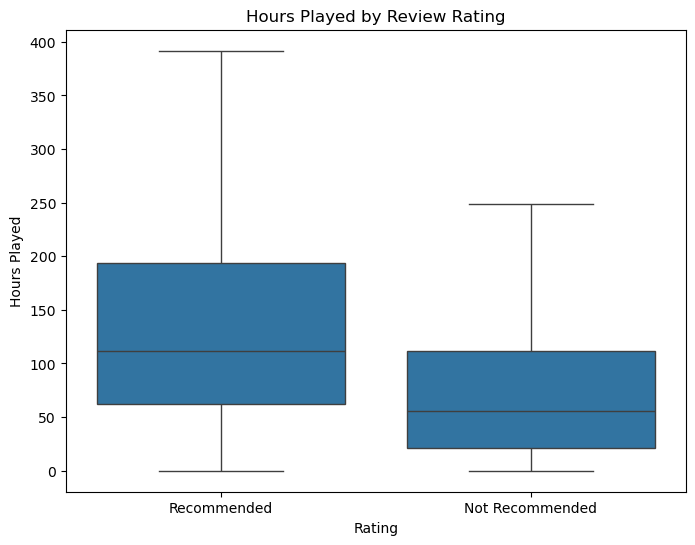

In [57]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Hours Played",
    showfliers=False # remove outliers to show the box more clearly
)

plt.title("Hours Played by Review Rating")
plt.ylabel("Hours Played")

plt.show()

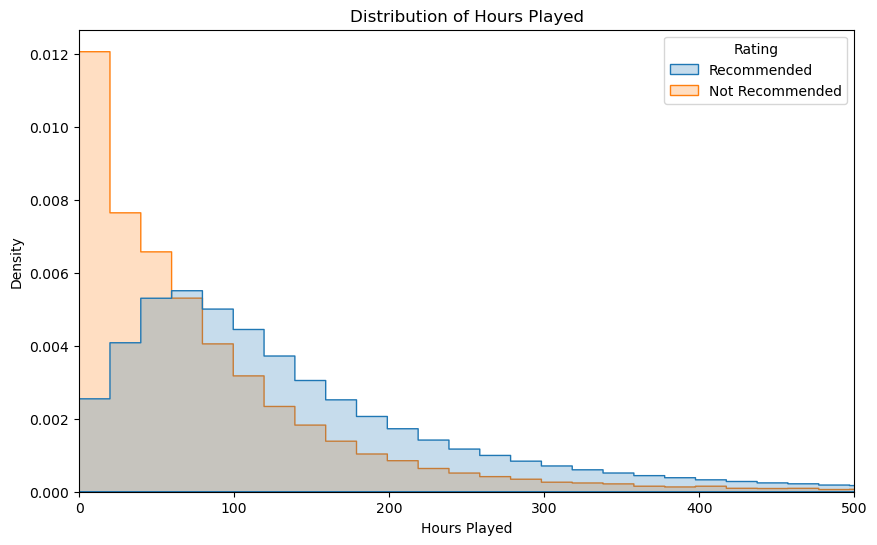

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Hours Played",
    hue="Rating",
    bins=1500,
    stat="density",
    common_norm=False,
    element="step"
)

plt.xlim(0,500)

plt.title("Distribution of Hours Played")

plt.show()

Above is a density plot of hours played vs. whether or not they recommend the game. As shown in the chart, more players who do not recommend the game tend to have lower playtimes, more specifically in the 0-60 hour mark. As players play more of the game, they tend to leave a more positive review.

Both distributions are right-skewed. This means that most players, regardless of rating, have low playtime.

#### Purchase Status / Received for Free

We can also take a look at each player's purchase status for this game. Do players who receive the game tend to leave a more favourable review?

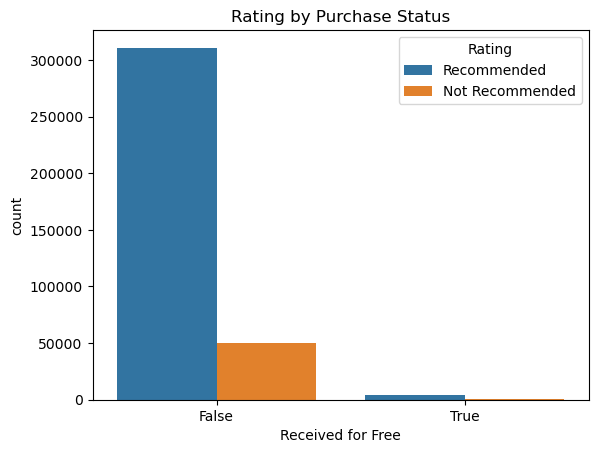

In [61]:
sns.countplot(
    data=df,
    x="Received for Free",
    hue="Rating"
)

plt.title("Rating by Purchase Status")
plt.show()

It's a bit hard to read, so we'll pivot to a percentage-based view of the data:

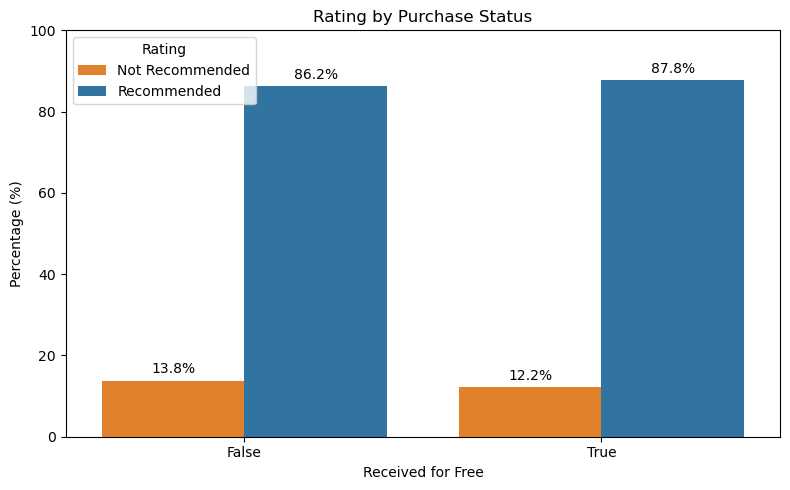

In [63]:
# Calculate percentages
percent_df = (
    pd.crosstab(
        df["Received for Free"],
        df["Rating"],
        normalize="index"
    ) * 100
).reset_index().melt(
    id_vars="Received for Free",
    var_name="Rating",
    value_name="Percentage"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=percent_df,
    x="Received for Free",
    y="Percentage",
    hue="Rating",
    palette=["tab:orange", "tab:blue"]  # Flipped colors
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.ylabel("Percentage (%)")
plt.xlabel("Received for Free")
plt.title("Rating by Purchase Status")
plt.ylim(0, 100)
plt.legend(title="Rating")

plt.tight_layout()
plt.show()

It seems that there isn't too much of a difference if a player received the game for free or not. There is only a 1.6% difference between the not recommended reviews out of the whole. 

#### Interpretation and Analysis

Based on these findings, we see that the distribution for playtime is right skewed, meaning that most players play under 100 hours. The distribution for those who do not recommend the game fall mostly between 0-60 hours, whereas those who do recommend the game fall between 60-100 hours. We also find that there isn't an observable difference between purchase status or not whether or not they recommend the game or not in their reviews. With this in mind, let's evaluate the options so far:

**Option A: Advertising**: 

**Option B: Communication**: 

**Option C: Complaint Analysis**: 

### Review Characteristics

Next, we'll take a look at the the characteristics of the reviews (helpful votes, length, correlations, etc.).

#### Review Length

Longer reviews usually mean that the feedback is more detailed, while shorter ones might just be approval or disapproval. We can create this feature and compare between recommended and not recommended reviews.

In [69]:
# Create review length

df["Review Length"] = (
    df["Review"]
      .fillna("")
      .str.split()
      .str.len()
)

In [70]:
df.groupby("Rating")["Review Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,88.536213,168.149093,0.0,7.0,28.0,92.0,1572.0
Recommended,315005.0,44.353601,108.025052,0.0,2.0,11.0,38.0,2000.0


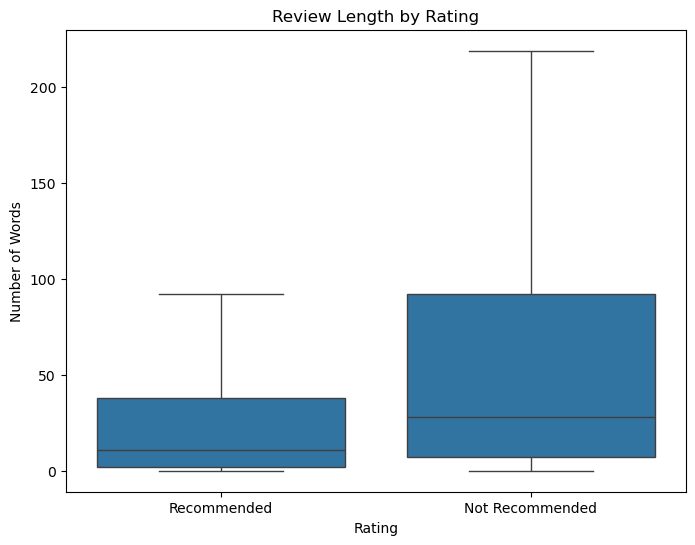

In [71]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Review Length",
    showfliers=False  # remove outliers to show the box more clearly
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Words")

plt.show()

Looking at the distribution, it seems like it is right skewed. It seems that the recommended reviews are shorter in general with a lower average and median. This makes sense as negative reviews would provide more detailed explanations for their dissatisfaction of the game.

#### Helpful Votes

Taking a look at the reviews' helpful votes can let us know if they are useful or not.

In [74]:
df.groupby("Rating")["Voted Helpful"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,5.474009,125.068857,0.0,0.0,1.0,2.0,12367.0
Recommended,315005.0,1.561426,69.781851,0.0,0.0,0.0,1.0,20111.0


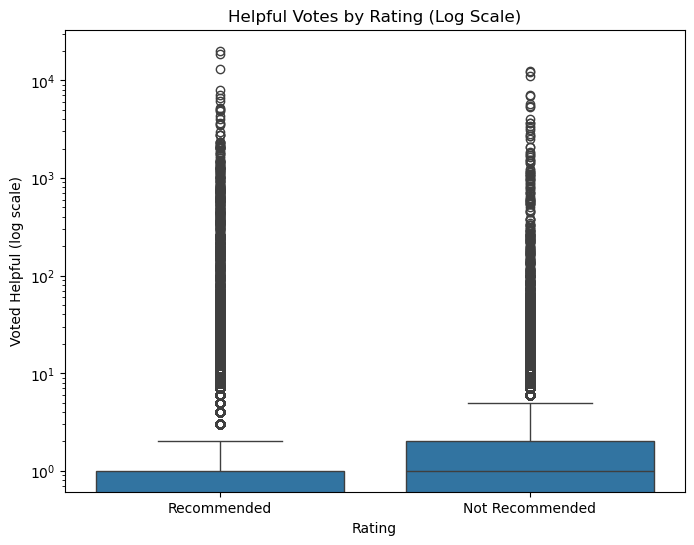

In [75]:
plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df,
    x="Rating",
    y="Voted Helpful"
)

ax.set_yscale("log") # set to log scale to make it easier to read

plt.title("Helpful Votes by Rating (Log Scale)")
plt.ylabel("Voted Helpful (log scale)")
plt.show()

It seems that negative reviews receive more helpful votes on average, meaning that other players find these reviews more informative. However, a majority of the reviews are low anyway. 

#### Review Length vs Helpful Votes

We can take a look at whether or not helpful votes correlate with the review length. Does a longer review result in a more helpful review?

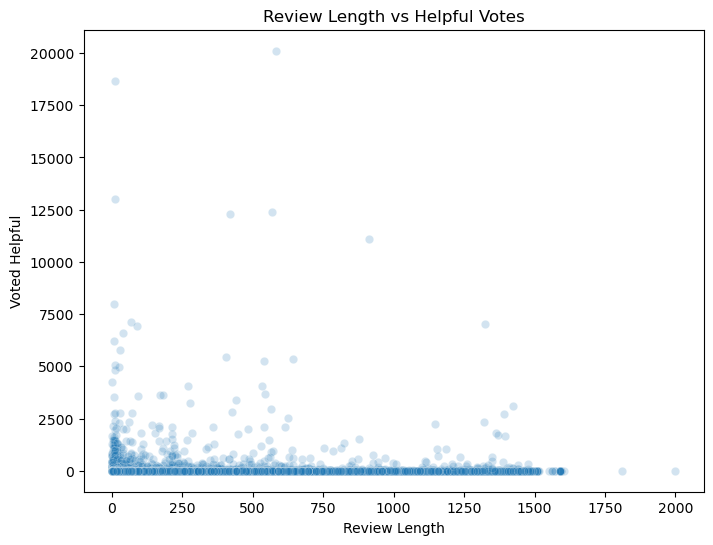

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")

plt.show()

Doesn't look like much. Let's zoom in on that cluster at the bottom left to make sure:

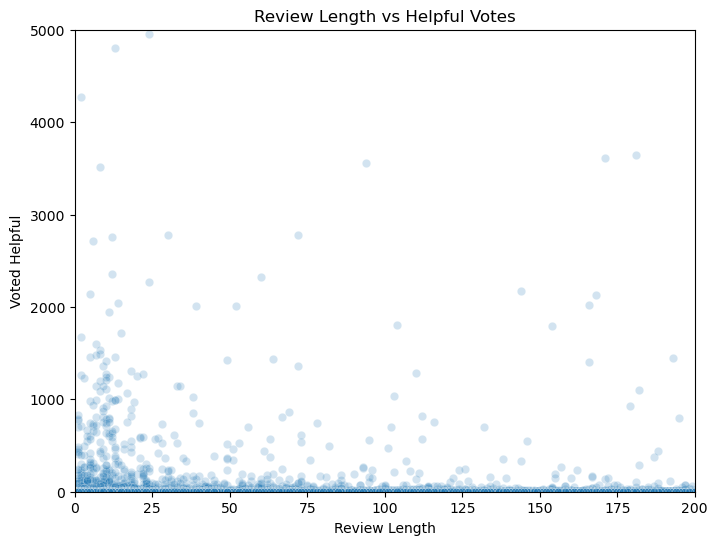

In [80]:
plot_df = df[
    (df["Voted Helpful"] <= 5000) &
    (df["Review Length"] <= 200)
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")
plt.xlim(0, 200)
plt.ylim(0, 5000)

plt.show()

There doesn't seem to be much correlation between the two as most reviews sit at 0 helpful votes. The top reviews seem to just be short and sweet. Out of curiosity, let's take a look:

In [82]:
df.loc[
    df["Voted Helpful"] > 12000,
    ["Voted Helpful", "Review"]
].sort_values("Voted Helpful", ascending=False)

,Voted Helpful,Review
4033,20111,DOWNLOAD THE NVIDIA GAME READY DRIVERS FOR THE...
94,18652,They made a 18+ gameThey also waited for every...
131251,13022,Just remember:Angel is a dude.Skye is a chick....
5122,12367,All the negative reviews thus far are about th...
176883,12286,Everyone complained about the bugs and glitche...


That's a very helpful top review.

#### Correlation between Numeric Features

Now let's just take in all of the numeric features and just look at the correlation matrix:

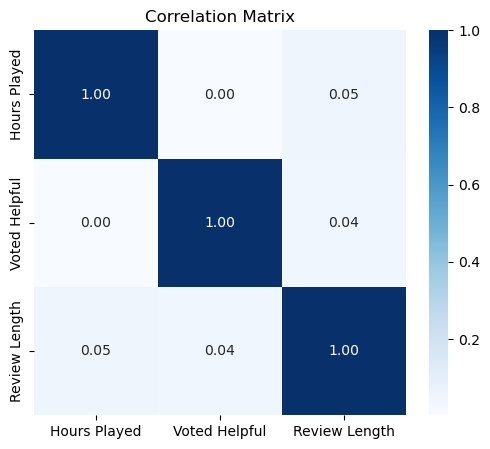

In [85]:
numeric = df[[
    "Hours Played",
    "Voted Helpful",
    "Review Length"
]]

corr = numeric.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

There does not seem to be a correlation whatsoever between `Hours Played`, `Voted Helpful`, and `Review Length`.

#### Interpretation and Analysis

Based on these findings, we see that there is an increase in review length for negative reviews than positive ones, probably due to the fact that these negative reviews have more to say than the positive ones. We also find that there are no correlations between `Hours Played`, `Voted Helpful`, and `Review Length`. This information doesn't really do much for either of the first two options, but since the negative reviews are more detailed/lengthy, we can have much more to work with for Option C if we decide to go with it.

### Negative Review Text

To get started on determining if Option C is viable, we need to do a bit of NLP. We need to see if there are any recurring complaint themes that are worth analyzing.

In [90]:
# Get the negative reviews that aren't empty 

negative_reviews = df[(df["Rating"] == "Not Recommended") & (df["Review"].notna())].copy()

print(len(negative_reviews))

50234


We have 50234 total reviews we can work with.

#### Text Preprocessing

In [99]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [
        word for word in text.split()
        if word not in stop_words
    ]
    return words

In [101]:
negative_reviews["tokens"] = (
    negative_reviews["Review"]
    .apply(preprocess)
)

#### Text Processing

Using nltk and regular expressions and spacy and custom stopwords (shoutout to my LING special topics class that we did NLP in), we can get the 20 most common words in our negative reviews.

In [103]:
custom_stopwords = {
    "game", "games", "play", "played", "playing",
    "player", "players", "steam",
    "like", "get", "got", "one",
    # I seem to not have done my tokenizing correctly so I just added the contractions into my stopwords
    "t", "s", "m", "ve", "re", "ll", "d",
    "don", "doesn", "didn", "isn", "aren",
    "wasn", "weren", "won", "would", "could",
    "also", "really", "even"
}

stop_words = STOP_WORDS | custom_stopwords

all_words = [
    word
    for tokens in negative_reviews["tokens"]
    for word in tokens
    if word not in stop_words
]

word_counts = Counter(all_words)

word_counts.most_common(20)

[('story', 17246),
 ('bugs', 17219),
 ('good', 12205),
 ('time', 11879),
 ('world', 10909),
 ('cyberpunk', 8278),
 ('character', 7641),
 ('bad', 7537),
 ('hours', 6885),
 ('feels', 6620),
 ('way', 6501),
 ('cdpr', 6464),
 ('city', 6360),
 ('feel', 6316),
 ('better', 6289),
 ('ai', 5842),
 ('fun', 5799),
 ('lot', 5766),
 ('people', 5759),
 ('years', 5687)]

There are some interesting topics to look into like "story", "world", or "ai", but we'll be able to learn more if we looked at the bigrams:

In [105]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

bigrams[:20]

[('open world', 4035),
 ('feels like', 2862),
 ('cyberpunk 2077', 2641),
 ('main story', 2417),
 ('game just', 2351),
 ('night city', 2189),
 ('feel like', 2181),
 ('play game', 1976),
 ('recommend game', 1789),
 ('game breaking', 1573),
 ('game play', 1490),
 ('good game', 1383),
 ('buy game', 1341),
 ('current state', 1308),
 ('like game', 1288),
 ('cd projekt', 1208),
 ('playing game', 1128),
 ('bugs glitches', 1091),
 ('projekt red', 1015),
 ('game like', 1001)]

We have topics like "open world", "main story", and "game breaking". We don't really have topics but maybe we can filter these out more later. Let's also look at the trigrams while we're here:

In [106]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3,3),
    max_features=20
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

bigrams[:20]

[('cd projekt red', 965),
 ('game breaking bugs', 695),
 ('open world game', 695),
 ('trash game trash', 622),
 ('game trash game', 620),
 ('cd project red', 499),
 ('bugs bugs bugs', 449),
 ('game feels like', 434),
 ('bug bug bug', 415),
 ('game current state', 391),
 ('open world rpg', 358),
 ('fraud fraud fraud', 334),
 ('open world games', 303),
 ('don buy game', 262),
 ('liars liars liars', 254),
 ('main story line', 245),
 ('early access game', 234),
 ('recommend game current', 203),
 ('game ve played', 201),
 ('www youtube com', 187)]

These are negative reviews alright... There aren't really any specific topics in these trigrams. Perhaps when we look at more of the list there will be more.

#### Interpretation and Analysis

Based on these findings, we see that there are a few topics we can look into when it comes to NLP and clustering. The top words/bigrams/trigrams are more general negative words to describe the game rather than certain topics. Option C can still be used to group these reviews, but we will have to dig deeper to find these topics within the reviews.

### Final Recommendation

(talk more about whether or not option a, b, or c makes the most sense)

## Short Progress Report (MILESTONE 1)

Went through the data extensively. Changing my approach to the assignment from:
> for Option A, I plan to look at newer-player reviews (lower playtime etc.) and see what the sentiment is, while for Option B, I plan to look at older-player reviews (inverse of above). For option C, using NLP to figure out common words that the negative reviews have.

to a more holistic view of the data and drawing conclusions from each of these parts:
1. Timeline of the Reviews (looking at the dates to figure out if there are any trends in reviews at certain times)
2. Player Characteristics (looking at reviewers' statistics, their playtime and whether or not they received the game for free and compare it to their rating)
3. Review Characteristics (looking into review length, how helpful other people find their review, and general correlations between features)
4. Negative Review Text Processing (looking to see if there are any glaring common themes in the negative reviews to strictly see if Option C is viable)

I am still continuing with finalizing my findings from the EDA.